# Notebook 1 — Data Ingestion

Pull every data source we need into `data/raw/` and `data/processed/`, then
print a validation summary at the bottom (this is the cell to screenshot for
the proposal).

Cells that require API keys are guarded: if the key isn't set in `.env`,
the cell prints a skip message instead of crashing, so the notebook is
runnable end-to-end at any point in setup.

Run order: top to bottom. All cells cache to disk, so reruns are cheap.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path

# Make `src/` importable when running from notebooks/.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')

from src import config
from src.config import (
    DEMO_STATIONS, RAW_DIR, PROCESSED_DIR, CACHE_DIR,
    LTA_ACCOUNT_KEY, ONEMAP_EMAIL, ONEMAP_PASSWORD,
)

print(f'Project root: {PROJECT_ROOT}')
print(f'Raw dir:       {RAW_DIR}')
print(f'Processed dir: {PROCESSED_DIR}')
print(f'Cache dir:     {CACHE_DIR}')
print()
print('Env vars present:')
print(f'  LTA_ACCOUNT_KEY:   {"yes" if LTA_ACCOUNT_KEY else "NO — LTA cells will skip"}')
print(f'  ONEMAP_EMAIL:      {"yes" if ONEMAP_EMAIL else "NO — OneMap cells will skip"}')
print(f'  ONEMAP_PASSWORD:   {"yes" if ONEMAP_PASSWORD else "NO — OneMap cells will skip"}')
print()
print(f'Demo stations: {[s.name for s in DEMO_STATIONS]}')

Project root: C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage
Raw dir:       C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage\data\raw
Processed dir: C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage\data\processed
Cache dir:     C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage\data\cache

Env vars present:
  LTA_ACCOUNT_KEY:   yes
  ONEMAP_EMAIL:      yes
  ONEMAP_PASSWORD:   yes

Demo stations: ['Jurong Fire Station', 'Bishan Fire Station', 'Tampines Fire Station', 'Central Fire Station']


## 2. LTA DataMall — Traffic Speed Bands

Endpoint: `TrafficSpeedBands`. Paginated with `$skip` in steps of 500. We
fetch every page, write raw JSON to `data/raw/`, and save a parsed parquet
with `LinkID, RoadName, MinSpeed, MaxSpeed, SpeedBand, StartLat/Lng, EndLat/Lng`.

In [2]:
speedbands_df = None
if LTA_ACCOUNT_KEY:
    from src.data_loaders import fetch_lta_speedbands
    speedbands_df = fetch_lta_speedbands()
    print(f'Fetched {len(speedbands_df):,} speed bands')
    display(speedbands_df.head())
    null_counts = speedbands_df.isna().sum()
    null_counts = null_counts[null_counts > 0]
    if not null_counts.empty:
        print('\nColumns with nulls:')
        print(null_counts)
    else:
        print('\nNo nulls in any column.')
else:
    print('SKIPPED: LTA_ACCOUNT_KEY not set. Add it to .env and rerun.')

2026-05-25 21:42:28,628 INFO src.data_loaders: Saved 56785 speed bands to C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage\data\processed\speedbands.parquet


Fetched 56,785 speed bands


,LinkID,RoadName,RoadCategory,SpeedBand,MinimumSpeed,MaximumSpeed,StartLng,StartLat,EndLng,EndLat
0,103011995,NARAYANAN CHETTY ROAD,E,2,10,19,103.83838061586873,1.2921590838224843,103.83817446261223,1.2917846048262231
1,103076902,RIVER VALLEY ROAD,B,5,40,49,103.84010402084176,1.295904895647087,103.83881860907599,1.295778586140851
2,103085351,BARTLEY ROAD,B,7,60,69,103.88146411588032,1.3420255972905863,103.88186075458927,1.3418453134509019
3,103007935,MUTHURAMAN CHETTY ROAD,E,3,20,29,103.83762351307742,1.2921118050279892,103.83797275045582,1.2926461393409348
4,103012043,MARTIN ROAD,E,4,30,39,103.83817446261223,1.2917846048262231,103.83840296152836,1.2916111381542603



No nulls in any column.


## 3. LTA DataMall — Traffic Incidents

Snapshot of currently-reported incidents. Used later as a feature signal.

In [3]:
incidents_df = None
if LTA_ACCOUNT_KEY:
    from src.data_loaders import fetch_lta_incidents
    incidents_df = fetch_lta_incidents()
    print(f'Fetched {len(incidents_df):,} incidents')
    if not incidents_df.empty:
        display(incidents_df.head())
    else:
        print('(No active incidents right now.)')
else:
    print('SKIPPED: LTA_ACCOUNT_KEY not set.')

2026-05-25 21:42:29,620 INFO src.data_loaders: Saved 9 incidents to C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage\data\processed\incidents.parquet


Fetched 9 incidents


,Type,Latitude,Longitude,Message
0,Roadwork,1.321968,103.664189,(25/5)21:36 Road Works on AYE (towards Tuas) a...
1,Obstacle,1.372181,103.778259,(25/5)21:30 Obstacle on BKE (towards PIE) at B...
2,Roadwork,1.361177,103.960062,(25/5)21:22 Road Works on TPE (towards SLE) at...
3,Roadwork,1.358865,103.961644,(25/5)21:22 Road Works on TPE (towards SLE) at...
4,Roadwork,1.358767,103.961734,(25/5)21:21 Road Works on TPE (towards SLE) at...


## 4. OneMap — Token + Sample Routing Test

Fetch a OneMap token (cached to disk with expiry) and do one test routing
call to confirm it works. We will NOT use OneMap as the main road network
(see section 5), but we may use it for geocoding.

In [4]:
if ONEMAP_EMAIL and ONEMAP_PASSWORD:
    token = config.get_onemap_token()
    print(f'Token (truncated): {token[:20]}...')
    from src.data_loaders import onemap_route
    # Bishan → Central
    route = onemap_route(1.3525, 103.8497, 1.2986, 103.8505, route_type='drive')
    summary = route.get('route_summary', {})
    if summary:
        print(f'Bishan → Central: {summary.get("total_distance", 0)/1000:.2f} km, '
              f'~{summary.get("total_time", 0)/60:.1f} min')
    else:
        print('Routing returned no summary; raw response:')
        print(json.dumps(route, indent=2)[:500])
else:
    print('SKIPPED: OneMap credentials not set.')

Token (truncated): eyJhbGciOiJSUzI1NiIs...


Bishan → Central: 10.46 km, ~15.2 min


## 5. OpenStreetMap — Singapore road network via osmnx

Pulls the full Singapore drivable road network. **This takes a few minutes**
on first run. Subsequent runs load from the pickle on disk.

We use OSM rather than OneMap as the road graph because osmnx + networkx give
us cheap shortest-path / isochrone computation, and OSM tags include road
class which we use as a feature.

In [5]:
import osmnx as ox
from src.network import NETWORK_PICKLE, load_road_network, save_road_network

if NETWORK_PICKLE.exists():
    print(f'Loading cached network from {NETWORK_PICKLE}...')
    G = load_road_network()
else:
    print('Building Singapore road network from OSM (this takes a few minutes)...')
    G = ox.graph_from_place('Singapore', network_type='drive')
    save_road_network(G)
    print(f'Saved to {NETWORK_PICKLE}')

print(f'Nodes: {G.number_of_nodes():,}')
print(f'Edges: {G.number_of_edges():,}')

Loading cached network from C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage\data\processed\sg_road_network.pkl...


Nodes: 24,214
Edges: 46,082


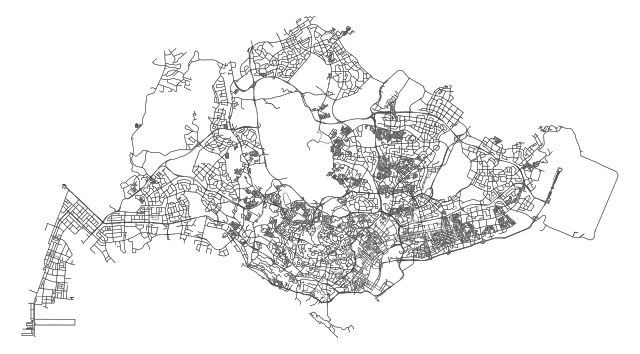

In [6]:
# Sanity-check plot. May be slow for the full graph; downsample if needed.
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.3,
    edge_color='#444444',
    bgcolor='white',
    show=True,
    close=False,
)

## 6. NEA — Current Rainfall

No auth required. Returns station-level rainfall readings (mm).

For historical readings we pass `date_time` (ISO-8601) to the same endpoint.

In [7]:
from src.data_loaders import fetch_nea_rainfall

rainfall_df = fetch_nea_rainfall()
print(f'Fetched {len(rainfall_df)} rainfall readings')
display(rainfall_df.head())
print(f'\nMax rainfall (mm/5min): {rainfall_df["rainfall_mm"].max():.2f}')
print(f'Stations reporting >0mm: {(rainfall_df["rainfall_mm"] > 0).sum()}')

2026-05-25 21:42:47,443 INFO src.data_loaders: Saved 75 rainfall readings to C:\Users\wenji\Downloads\scdf-coverage-extracted\scdf-coverage\data\processed\rainfall_latest.parquet


Fetched 75 rainfall readings


,station_id,station_name,lat,lng,rainfall_mm,timestamp
0,S77,Alexandra Road,1.29370,103.81270,0,2026-05-25T21:35:00+08:00
1,S216,Ang Mo Kio Avenue 10,1.36019,103.85335,0,2026-05-25T21:35:00+08:00
2,S109,Ang Mo Kio Avenue 5,1.37930,103.85000,0,2026-05-25T21:35:00+08:00
3,S117,Banyan Road,1.25420,103.67410,0,2026-05-25T21:35:00+08:00
4,S129,Bedok Stadium,1.32575,103.93969,0,2026-05-25T21:35:00+08:00



Max rainfall (mm/5min): 0.00
Stations reporting >0mm: 0


## 7. Fire Stations

We use the hardcoded `DEMO_STATIONS` list from `src/config.py`. For reference,
the official dataset is the Fire Stations resource on data.gov.sg:

https://beta.data.gov.sg/datasets?formats=GEOJSON&query=fire%20station

If we need to swap in canonical coordinates later, pull from that dataset.

In [8]:
import pandas as pd
stations_df = pd.DataFrame([{
    'id': s.id, 'name': s.name, 'lat': s.lat, 'lng': s.lng, 'address': s.address
} for s in DEMO_STATIONS])
display(stations_df)

,id,name,lat,lng,address
0,jurong,Jurong Fire Station,1.3329,103.7436,"200 Yuan Ching Rd, Singapore 618660"
1,bishan,Bishan Fire Station,1.3525,103.8497,"120 Bishan St 12, Singapore 579809"
2,tampines,Tampines Fire Station,1.3548,103.9421,"400 Tampines Ave 5, Singapore 529648"
3,central,Central Fire Station,1.2986,103.8505,"62 Hill St, Singapore 179367"


## 8. Validation Summary

Screenshot this cell for the proposal.

In [9]:
summary_rows = []

def _row(source, status, count, path):
    summary_rows.append({
        'source': source, 'status': status,
        'rows': count, 'path': str(path) if path else '',
    })

# LTA speedbands
p = PROCESSED_DIR / 'speedbands.parquet'
if speedbands_df is not None:
    _row('LTA TrafficSpeedBands', 'ok', len(speedbands_df), p)
elif p.exists():
    _row('LTA TrafficSpeedBands', 'cached', len(pd.read_parquet(p)), p)
else:
    _row('LTA TrafficSpeedBands', 'skipped (no key)', 0, '')

# LTA incidents
p = PROCESSED_DIR / 'incidents.parquet'
if incidents_df is not None:
    _row('LTA TrafficIncidents', 'ok', len(incidents_df), p)
elif p.exists():
    _row('LTA TrafficIncidents', 'cached', len(pd.read_parquet(p)), p)
else:
    _row('LTA TrafficIncidents', 'skipped (no key)', 0, '')

# OSM network
if NETWORK_PICKLE.exists():
    _row('OSM road network', 'ok', G.number_of_edges(), NETWORK_PICKLE)
else:
    _row('OSM road network', 'missing', 0, '')

# NEA rainfall
p = PROCESSED_DIR / 'rainfall_latest.parquet'
if not rainfall_df.empty:
    _row('NEA rainfall', 'ok', len(rainfall_df), p)
else:
    _row('NEA rainfall', 'empty', 0, p)

# Stations
_row('Demo stations (hardcoded)', 'ok', len(DEMO_STATIONS), 'src/config.py')

# OneMap (no row count — credential check only)
_row(
    'OneMap token',
    'ok' if (ONEMAP_EMAIL and ONEMAP_PASSWORD) else 'skipped (no creds)',
    1 if (ONEMAP_EMAIL and ONEMAP_PASSWORD) else 0,
    CACHE_DIR / 'onemap_token.json' if (ONEMAP_EMAIL and ONEMAP_PASSWORD) else '',
)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,source,status,rows,path
0,LTA TrafficSpeedBands,ok,56785,C:\Users\wenji\Downloads\scdf-coverage-extract...
1,LTA TrafficIncidents,ok,9,C:\Users\wenji\Downloads\scdf-coverage-extract...
2,OSM road network,ok,46082,C:\Users\wenji\Downloads\scdf-coverage-extract...
3,NEA rainfall,ok,75,C:\Users\wenji\Downloads\scdf-coverage-extract...
4,Demo stations (hardcoded),ok,4,src/config.py
5,OneMap token,ok,1,C:\Users\wenji\Downloads\scdf-coverage-extract...
